# CatBoost Swing Trading Model
Multi-class classifier (`-1` / `0` / `1`) trained on Triple Barrier labels.

| Label | Meaning |
|---|---|
| `1` | Take-Profit hit within horizon |
| `-1` | Stop-Loss hit within horizon |
| `0` | Time expiry — neither barrier reached |

**Panel dataset** — 50 tickers stacked vertically, features computed per-ticker via `.groupby('Ticker')` to prevent cross-contamination. Evaluation uses a strict chronological split (no random shuffling).

## Cell 1 — Setup & Data Loading

In [36]:
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------------------------
# Path constants
# ---------------------------------------------------------------------------
LABELED_DIR: str = "data/labeled"
MODEL_DIR: str = "data/models"

os.makedirs(MODEL_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Load & stack all labeled CSVs into a single panel DataFrame
# ---------------------------------------------------------------------------
files: list[str] = sorted(glob(os.path.join(LABELED_DIR, "*_labeled.csv")))

if not files:
    raise FileNotFoundError(
        f"No labeled CSVs found in '{LABELED_DIR}'. "
        "Run label_generator.ipynb first."
    )

frames: list[pd.DataFrame] = []
for path in files:
    ticker: str = os.path.basename(path).replace("_labeled.csv", "")
    df: pd.DataFrame = pd.read_csv(path, parse_dates=["Date"])
    df["Ticker"] = ticker
    frames.append(df)

master: pd.DataFrame = (
    pd.concat(frames, ignore_index=True)
    .sort_values(["Ticker", "Date"])
    .reset_index(drop=True)
)

print(f"Loaded {len(files)} tickers  |  master shape: {master.shape}")
print(f"Date range : {master['Date'].min().date()} → {master['Date'].max().date()}")
print(f"Target dist:\n{master['Target'].value_counts().sort_index()}")

Loaded 50 tickers  |  master shape: (107510, 20)
Date range : 2016-05-09 → 2026-04-30
Target dist:
Target
-1    30923
 0     7010
 1    69577
Name: count, dtype: int64


## Cell 2 — Feature Engineering (Grouped by Ticker)

All rolling windows and percent-change operations are applied **inside** `.groupby('Ticker')`
to prevent cross-ticker contamination.  Every feature is computed on data that would have
been observable *before* the close of bar `i` — no lookahead.

| Feature | Group | Description |
|---|---|---|
| `Price_Pct_Change_1D` | Momentum | 1-day `adjusted_close` return |
| `SPY_Pct_Change_3D` | Momentum | 3-day SPY return (market regime) |
| `Overnight_Gap_ES` | Momentum | `(ESF_Close − prev_close) / prev_close` — macro gap |
| `RSI_14` | Momentum | 14-day Wilder RSI |
| `Distance_from_20SMA` | Momentum | `(close / 20-day SMA) − 1` |
| `Sentiment_Z_Score` | Sentiment Surprise | `(avg_sentiment − 20d_mean) / (20d_std + 0.001)` |
| `Sentiment_Price_Divergence` | Sentiment Divergence | `avg_sentiment / (Price_Pct_Change_1D + 0.01)` — news price hasn't reacted to |
| `Sentiment_Vol_Conviction` | Conviction | `avg_sentiment × log1p(volume)` |
| `Sector_Rel_Sentiment` | Sector Relative | Ticker `avg_sentiment` minus daily cross-ticker mean |
| `Sentiment_Lag_1` | Leading Signal | `avg_sentiment` from the prior trading day |
| `avg_sentiment` | Sentiment Raw | Alpha Vantage daily average sentiment |
| `weighted_avg_sentiment` | Sentiment Raw | Relevance-weighted sentiment average |
| `max_sentiment` | Sentiment Raw | Most bullish article score on the day |
| `min_sentiment` | Sentiment Raw | Most bearish article score on the day |

In [37]:
def _rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Compute Wilder's RSI for a price series.

    Uses exponential moving average (Wilder smoothing, com = period - 1)
    rather than simple rolling mean to match standard RSI definitions.

    Parameters
    ----------
    series : pd.Series
        Raw price series (e.g. adjusted_close) for a single ticker,
        already sorted chronologically.
    period : int
        Lookback window (default 14).

    Returns
    -------
    pd.Series
        RSI values in [0, 100].
    """
    delta: pd.Series = series.diff()
    gain: pd.Series = delta.clip(lower=0)
    loss: pd.Series = (-delta).clip(lower=0)

    avg_gain: pd.Series = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss: pd.Series = loss.ewm(com=period - 1, min_periods=period).mean()

    rs: pd.Series = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute all predictive features on the panel DataFrame.

    Every operation is applied inside .groupby('Ticker') so that rolling
    windows never bleed across ticker boundaries. Cross-ticker aggregations
    (e.g. Sector_Rel_Sentiment) are computed on the full panel before groupby.

    Parameters
    ----------
    df : pd.DataFrame
        Master panel DataFrame with columns from the labeled CSVs plus
        a 'Ticker' column.

    Returns
    -------
    pd.DataFrame
        Original DataFrame with engineered feature columns appended.
        Rows containing NaNs introduced by rolling windows are dropped.
    """
    grp = df.groupby("Ticker", group_keys=False)

    # ------------------------------------------------------------------
    # 1. Core Momentum & Trend
    # ------------------------------------------------------------------
    df["Price_Pct_Change_1D"] = grp["adjusted_close"].transform(
        lambda s: s.pct_change(1)
    )

    df["SPY_Pct_Change_3D"] = grp["SPY_AdjClose"].transform(
        lambda s: s.pct_change(3)
    )

    df["Overnight_Gap_ES"] = grp.apply(
        lambda g: (g["ESF_Close"] - g["adjusted_close"].shift(1))
                  / g["adjusted_close"].shift(1)
    ).reset_index(level=0, drop=True)

    df["RSI_14"] = grp["adjusted_close"].transform(_rsi)

    df["Distance_from_20SMA"] = grp["adjusted_close"].transform(
        lambda s: (s / s.rolling(20).mean()) - 1
    )

    # ------------------------------------------------------------------
    # 2. Sentiment Surprise — Z-Score vs 20-day rolling baseline
    #    Captures when today's sentiment is unusually high/low relative
    #    to the ticker's own recent history.
    # ------------------------------------------------------------------
    df["Sentiment_Z_Score"] = grp["avg_sentiment"].transform(
        lambda s: (s - s.rolling(20).mean()) / (s.rolling(20).std() + 0.001)
    )

    # ------------------------------------------------------------------
    # 3. Sentiment Divergence — news the price hasn't reacted to yet
    #    High positive value = bullish sentiment but flat/down price.
    #    Small epsilon (+0.01) prevents division explosion near zero.
    # ------------------------------------------------------------------
    df["Sentiment_Price_Divergence"] = (
        df["avg_sentiment"] / (df["Price_Pct_Change_1D"] + 0.01)
    )

    # ------------------------------------------------------------------
    # 4. Conviction & Volume — sentiment weighted by trading activity
    #    log1p(volume) compresses the volume scale; high-volume days with
    #    strong sentiment signal institutional conviction.
    # ------------------------------------------------------------------
    df["Sentiment_Vol_Conviction"] = df["avg_sentiment"] * np.log1p(df["volume"])

    # ------------------------------------------------------------------
    # 5. Sector Relative Sentiment — cross-ticker daily mean subtracted
    #    Isolates whether a ticker is outperforming/underperforming the
    #    broad market's news tone on the same day.
    # ------------------------------------------------------------------
    df["Daily_Global_Avg_Sentiment"] = df.groupby("Date")["avg_sentiment"].transform(
        "mean"
    )
    df["Sector_Rel_Sentiment"] = df["avg_sentiment"] - df["Daily_Global_Avg_Sentiment"]

    # ------------------------------------------------------------------
    # 6. Lagged Leading Signal — prior day's sentiment
    #    Tests whether yesterday's news predicts today's price move.
    # ------------------------------------------------------------------
    df["Sentiment_Lag_1"] = grp["avg_sentiment"].transform(lambda s: s.shift(1))

    # ------------------------------------------------------------------
    # 7. News Volume Z-Score — abnormal article-count days
    #    Spikes in coverage often precede or accompany price moves.
    #    Formula: (article_count - 20d_mean) / (20d_std + 0.001)
    # ------------------------------------------------------------------
    df["News_Vol_Z"] = grp["article_count"].transform(
        lambda s: (s - s.rolling(20).mean()) / (s.rolling(20).std() + 0.001)
    )

    # Drop NaN rows created by rolling windows (no imputation for price/sentiment features)
    df = df.dropna().reset_index(drop=True)
    return df


featured: pd.DataFrame = engineer_features(master.copy())

ENGINEERED_COLS: list[str] = [
    "Price_Pct_Change_1D", "SPY_Pct_Change_3D", "Overnight_Gap_ES",
    "RSI_14", "Distance_from_20SMA",
    "Sentiment_Z_Score", "Sentiment_Price_Divergence",
    "Sentiment_Vol_Conviction", "Sector_Rel_Sentiment", "Sentiment_Lag_1",
    "News_Vol_Z",
]

print(f"Post-engineering shape : {featured.shape}")
print(f"Remaining NaNs         : {featured[ENGINEERED_COLS].isna().sum().sum()}")
featured[ENGINEERED_COLS].describe().round(4)

Post-engineering shape : (61791, 32)
Remaining NaNs         : 0


,Price_Pct_Change_1D,SPY_Pct_Change_3D,Overnight_Gap_ES,RSI_14,Distance_from_20SMA,Sentiment_Z_Score,Sentiment_Price_Divergence,Sentiment_Vol_Conviction,Sector_Rel_Sentiment,Sentiment_Lag_1,News_Vol_Z
count,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000,61791.0000
mean,0.0010,0.0015,111.7581,51.3764,0.0045,0.0080,5.4698,1.8466,0.0001,0.1156,0.0430
std,0.0380,0.0183,287.7384,12.5660,0.0938,1.0118,844.6663,3.3425,0.2062,0.2094,1.0189
min,-0.4195,-0.1065,2.7240,9.1523,-0.7059,-4.2284,-47951.4126,-16.7403,-1.0699,-0.9468,-4.2296
25%,-0.0162,-0.0080,23.1268,42.2014,-0.0448,-0.5014,0.0000,0.0000,-0.1230,0.0000,-0.6047
50%,0.0006,0.0029,38.6187,50.9897,0.0046,0.0000,0.0000,0.5156,-0.0497,0.0306,-0.1318
75%,0.0171,0.0119,83.6643,60.2931,0.0510,0.5297,9.0680,4.2806,0.1423,0.2647,0.4691
max,0.9522,0.0858,6764.3207,96.7876,2.6191,4.2274,167690.3647,16.6715,0.8377,0.9067,4.2479


## Cell 3 — Chronological Train / Test Split

The split is made on the **global date axis** — the first 75 % of unique trading days
form the training set; the last 25 % form the out-of-sample test set.
This preserves temporal ordering across all tickers simultaneously and prevents
any future bar from leaking into the training window.

In [ ]:
TRAIN_RATIO: float = 0.75

# Pruned high-conviction feature set.
FEATURE_COLS: list[str] = [
    "SPY_Pct_Change_3D",
    "Price_Pct_Change_1D",
    "Overnight_Gap_ES",
    "Sector_Rel_Sentiment",
    "Sentiment_Z_Score",
    "News_Vol_Z",
]

# Drop time-expiry rows — binary classification only (-1 and 1).
featured_binary: pd.DataFrame = featured[featured["Target"] != 0].copy()

# ---------------------------------------------------------------------------
# Chronological split on the global date axis
# ---------------------------------------------------------------------------
sorted_dates: np.ndarray = np.sort(featured_binary["Date"].unique())
split_idx: int = int(len(sorted_dates) * TRAIN_RATIO)
cutoff_date: pd.Timestamp = pd.Timestamp(sorted_dates[split_idx])

train_mask: pd.Series = featured_binary["Date"] < cutoff_date
test_mask: pd.Series  = featured_binary["Date"] >= cutoff_date

train_df: pd.DataFrame = featured_binary[train_mask].copy()
test_df: pd.DataFrame  = featured_binary[test_mask].copy()

X_train: pd.DataFrame = train_df[FEATURE_COLS]
y_train: pd.Series    = train_df["Target"]

X_test: pd.DataFrame  = test_df[FEATURE_COLS]
y_test: pd.Series     = test_df["Target"]

feature_cols: list[str] = FEATURE_COLS

print(f"Train cutoff   : {cutoff_date.date()}")
print(f"Train set      : {len(X_train):>6} rows  ({train_mask.mean():.0%} of data)")
print(f"Test  set      : {len(X_test):>6} rows  ({test_mask.mean():.0%} of data)")

print(f"Feature cols   : {feature_cols}")
print(f"\nTest  target dist:\n{y_test.value_counts().sort_index()}")
print(f"\nTrain target dist:\n{y_train.value_counts().sort_index()}")

SyntaxError: invalid syntax (1078638146.py, line 41)

## Cell 4 — CatBoost Training

`auto_class_weights='Balanced'` compensates for the heavy class-0 majority without
manually computing class weights.  Early stopping monitors the test eval set loss
and halts training if no improvement is seen for 50 rounds.

In [ ]:
MODEL_PATH: str = os.path.join(MODEL_DIR, "catboost_swing_v1.cbm")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100,
)

train_pool = Pool(X_train, y_train)
eval_pool  = Pool(X_test,  y_test)

model.fit(
    train_pool,
    eval_set=eval_pool,
    early_stopping_rounds=50,
    use_best_model=True,
)

model.save_model(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")
print(f"Best iteration : {model.get_best_iteration()}")

0:	learn: 0.4994683	test: 0.4646827	best: 0.4646827 (0)	total: 6.33ms	remaining: 6.32s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4885320768
bestIteration = 4

Shrink model to first 5 iterations.

Model saved to: data/models\catboost_swing_v1.cbm
Best iteration : 4


## Cell 5 — Evaluation & Feature Importance

OUT-OF-SAMPLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

     SL (-1)       0.53      0.34      0.41      7493
  Expiry (0)       0.17      0.74      0.27      1582
      TP (1)       0.47      0.28      0.35      6552

    accuracy                           0.35     15627
   macro avg       0.39      0.45      0.34     15627
weighted avg       0.47      0.35      0.37     15627



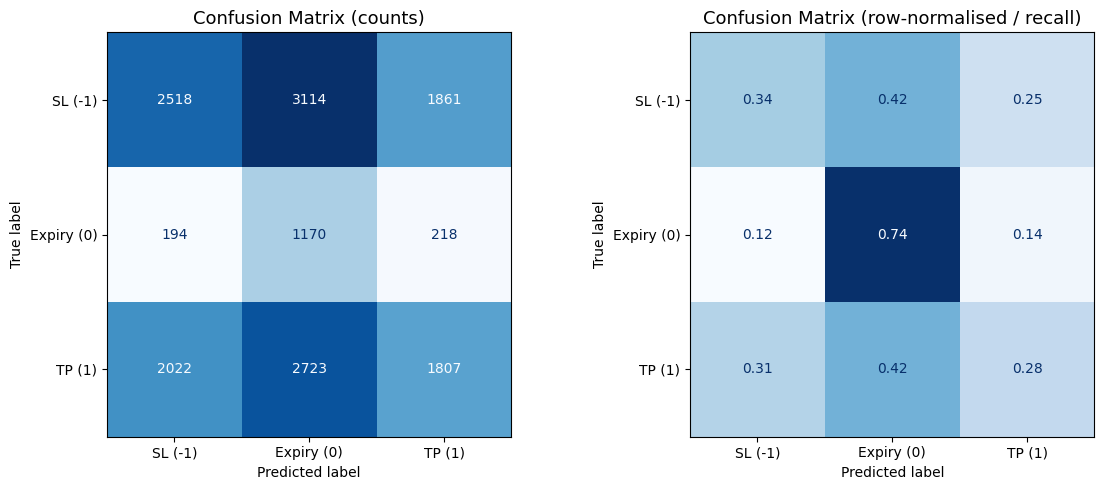

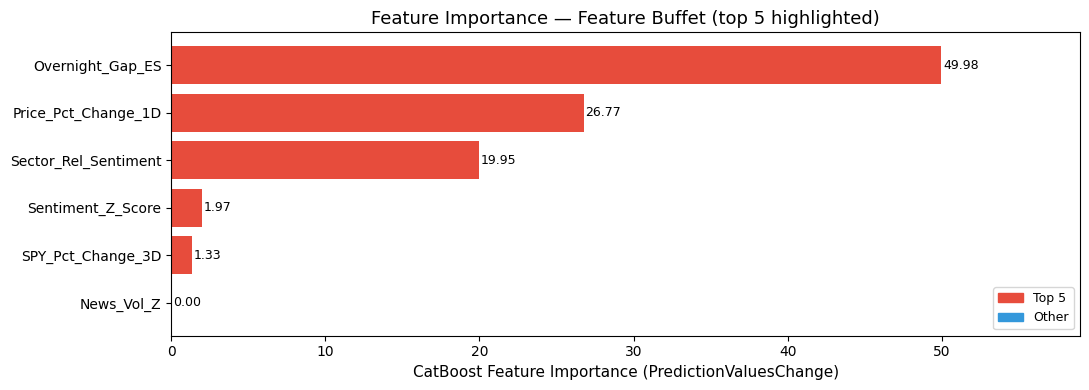


Feature Importance — Full Ranked Table
 Rank Top5              Feature  Importance  Pct_of_Total
    1    ★     Overnight_Gap_ES     49.9792         49.98
    2    ★  Price_Pct_Change_1D     26.7689         26.77
    3    ★ Sector_Rel_Sentiment     19.9513         19.95
    4    ★    Sentiment_Z_Score      1.9699          1.97
    5    ★    SPY_Pct_Change_3D      1.3307          1.33
    6                News_Vol_Z      0.0000          0.00


In [ ]:
y_pred: np.ndarray = model.predict(X_test).flatten().astype(int)
CLASS_LABELS: list[int] = [-1, 1]
CLASS_NAMES: list[str]  = ["SL (-1)", "TP (1)"]

# ---------------------------------------------------------------------------
# Classification report
# ---------------------------------------------------------------------------
print("=" * 60)
print("OUT-OF-SAMPLE CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, labels=CLASS_LABELS, target_names=CLASS_NAMES))

# ---------------------------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)", fontsize=13)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (row-normalised / recall)", fontsize=13)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Feature importance — sorted ascending; top 5 highlighted in red
# ---------------------------------------------------------------------------
importances: np.ndarray = model.get_feature_importance()
fi_df: pd.DataFrame = (
    pd.DataFrame({"Feature": feature_cols, "Importance": importances})
    .sort_values("Importance", ascending=True)
    .reset_index(drop=True)
)

TOP_N: int = 5
# fi_df is sorted ascending, so the last TOP_N rows are the highest-importance features
colors: list[str] = [
    "#e74c3c" if i >= len(fi_df) - TOP_N else "#3498db"
    for i in range(len(fi_df))
]

fig, ax = plt.subplots(figsize=(11, max(4, len(fi_df) * 0.5)))
bars = ax.barh(fi_df["Feature"], fi_df["Importance"], color=colors)
for i, imp in enumerate(fi_df["Importance"]):
    ax.text(imp + 0.1, i, f"{imp:.2f}", va="center", fontsize=9)

# Legend
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="#e74c3c", label="Top 5"), Patch(color="#3498db", label="Other")],
    loc="lower right",
    fontsize=9,
)
ax.set_xlabel("CatBoost Feature Importance (PredictionValuesChange)", fontsize=11)
ax.set_title("Feature Importance — Feature Buffet (top 5 highlighted)", fontsize=13)
ax.set_xlim(0, fi_df["Importance"].max() * 1.18)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Ranked importance table
# ---------------------------------------------------------------------------
ranked: pd.DataFrame = (
    fi_df.sort_values("Importance", ascending=False)
    .reset_index(drop=True)
    .rename_axis("Rank")
    .reset_index()
)
ranked["Rank"] += 1
ranked["Importance"] = ranked["Importance"].round(4)
ranked["Pct_of_Total"] = (ranked["Importance"] / ranked["Importance"].sum() * 100).round(2)
ranked["Top5"] = ranked["Rank"].apply(lambda r: "★" if r <= TOP_N else "")

print("\nFeature Importance — Full Ranked Table")
print("=" * 55)
print(ranked[["Rank", "Top5", "Feature", "Importance", "Pct_of_Total"]].to_string(index=False))